# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Load Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Student_Dropout_Prediction/student dropout.csv')

In [ ]:
df.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,False


In [ ]:
df.tail()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
644,MS,F,19,R,GT3,T,2,3,services,other,...,4,2,1,2,5,4,10,11,10,False
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,3,4,1,1,1,4,15,15,16,False
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,5,6,11,12,9,True
647,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,6,10,10,10,False
648,MS,M,18,R,LE3,T,3,2,services,other,...,4,1,3,4,5,4,10,11,11,False


# EDA (Exploratory Data Analysis)

In [ ]:
df.shape

(649, 34)

In [ ]:
df.columns

Index(['School', 'Gender', 'Age', 'Address', 'Family_Size', 'Parental_Status',
       'Mother_Education', 'Father_Education', 'Mother_Job', 'Father_Job',
       'Reason_for_Choosing_School', 'Guardian', 'Travel_Time', 'Study_Time',
       'Number_of_Failures', 'School_Support', 'Family_Support',
       'Extra_Paid_Class', 'Extra_Curricular_Activities', 'Attended_Nursery',
       'Wants_Higher_Education', 'Internet_Access', 'In_Relationship',
       'Family_Relationship', 'Free_Time', 'Going_Out',
       'Weekend_Alcohol_Consumption', 'Weekday_Alcohol_Consumption',
       'Health_Status', 'Number_of_Absences', 'Grade_1', 'Grade_2',
       'Final_Grade', 'Dropped_Out'],
      dtype='object')

In [ ]:
df.dtypes

,0
School,object
Gender,object
Age,int64
Address,object
Family_Size,object
Parental_Status,object
Mother_Education,int64
Father_Education,int64
Mother_Job,object
Father_Job,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   School                       649 non-null    object
 1   Gender                       649 non-null    object
 2   Age                          649 non-null    int64 
 3   Address                      649 non-null    object
 4   Family_Size                  649 non-null    object
 5   Parental_Status              649 non-null    object
 6   Mother_Education             649 non-null    int64 
 7   Father_Education             649 non-null    int64 
 8   Mother_Job                   649 non-null    object
 9   Father_Job                   649 non-null    object
 10  Reason_for_Choosing_School   649 non-null    object
 11  Guardian                     649 non-null    object
 12  Travel_Time                  649 non-null    int64 
 13  Study_Time                   649 no

In [ ]:
df.describe()

,Age,Mother_Education,Father_Education,Travel_Time,Study_Time,Number_of_Failures,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


# Data Cleaning

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
School,0
Gender,0
Age,0
Address,0
Family_Size,0
Parental_Status,0
Mother_Education,0
Father_Education,0
Mother_Job,0
Father_Job,0


# Correlation Heatmap

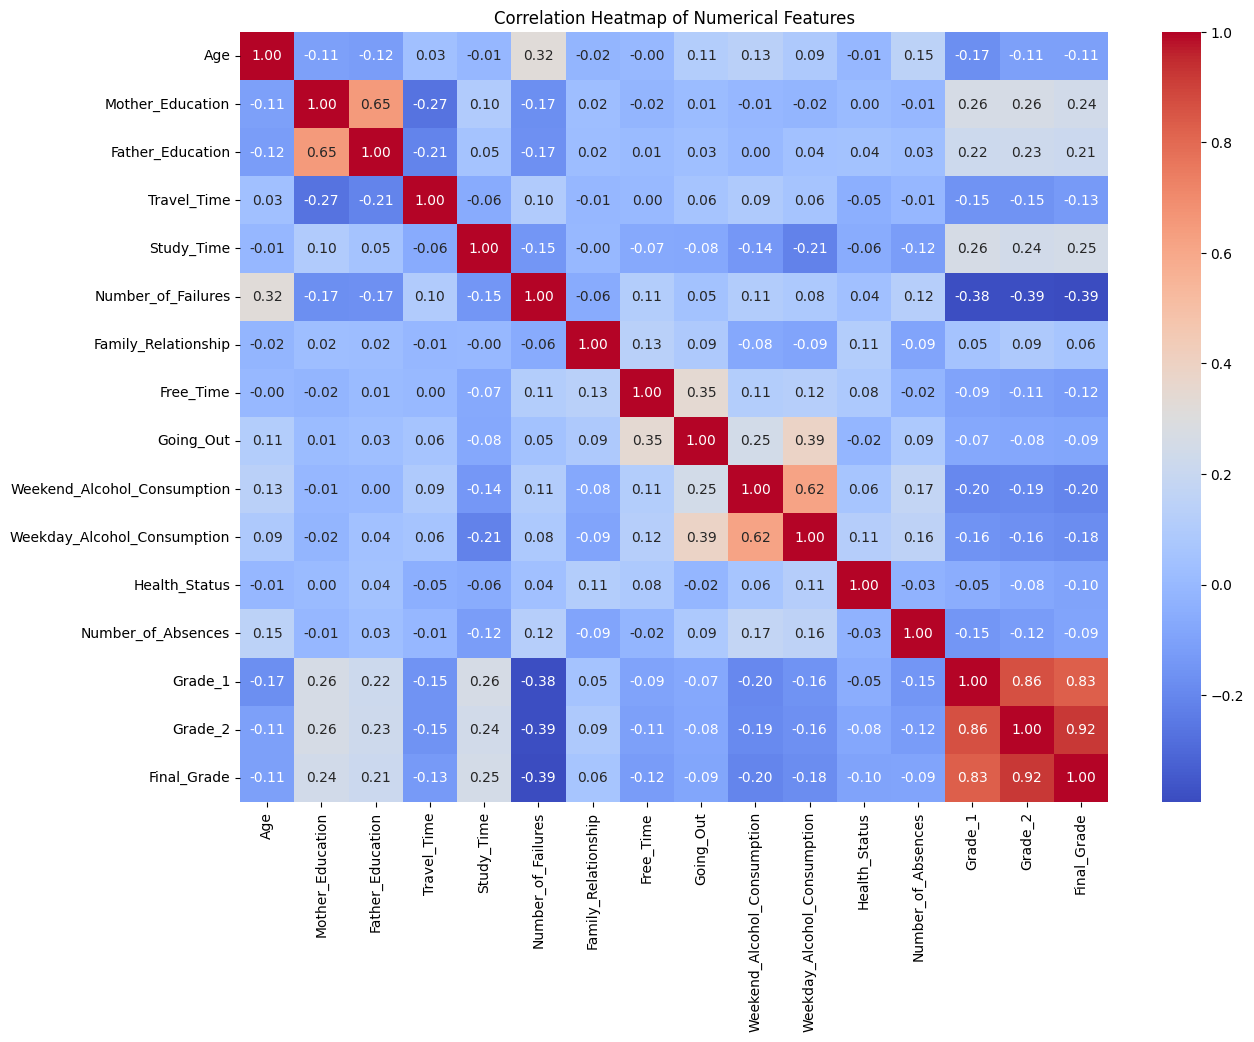

In [ ]:
plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [ ]:
correlation = df.select_dtypes(include=np.number).corrwith(
    df["Dropped_Out"].astype(int)
).sort_values()

print(correlation)

Final_Grade                   -0.663157
Grade_2                       -0.592251
Grade_1                       -0.563070
Study_Time                    -0.165111
Father_Education              -0.146249
Mother_Education              -0.144803
Family_Relationship           -0.044987
Health_Status                  0.009979
Travel_Time                    0.057869
Going_Out                      0.067241
Number_of_Absences             0.087483
Free_Time                      0.093349
Age                            0.110722
Weekday_Alcohol_Consumption    0.116249
Weekend_Alcohol_Consumption    0.123627
Number_of_Failures             0.380237
dtype: float64


# Dropout Distribution

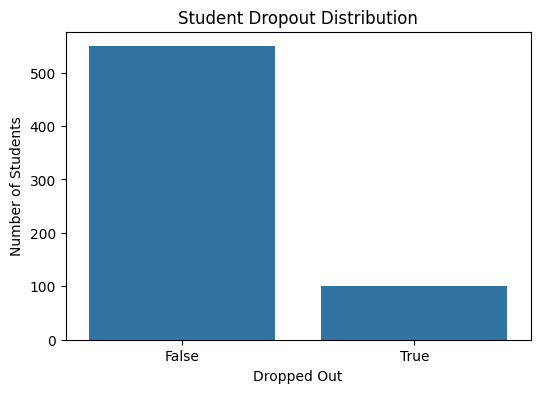

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Dropped_Out')

plt.title('Student Dropout Distribution')
plt.xlabel('Dropped Out')
plt.ylabel('Number of Students')
plt.show()

# Grade 1 vs Dropout

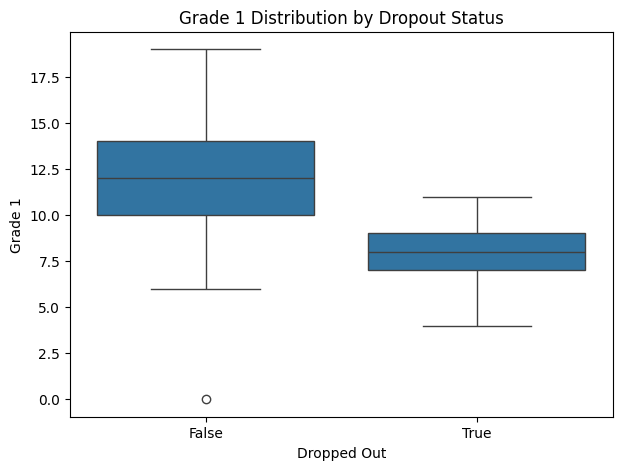

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Dropped_Out", y="Grade_1")

plt.title("Grade 1 Distribution by Dropout Status")
plt.xlabel("Dropped Out")
plt.ylabel("Grade 1")
plt.show()

# Grade 2 vs Dropout

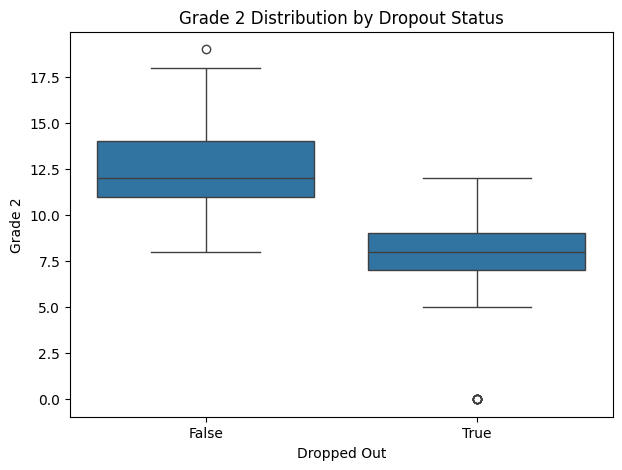

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Dropped_Out", y="Grade_2")

plt.title("Grade 2 Distribution by Dropout Status")
plt.xlabel("Dropped Out")
plt.ylabel("Grade 2")
plt.show()

# Final Grade vs Dropout

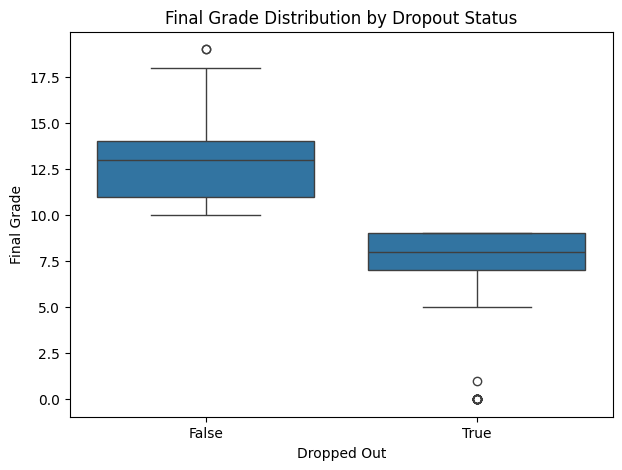

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Dropped_Out", y="Final_Grade")

plt.title("Final Grade Distribution by Dropout Status")
plt.xlabel("Dropped Out")
plt.ylabel("Final Grade")
plt.show()

# Number of Failures vs Dropout

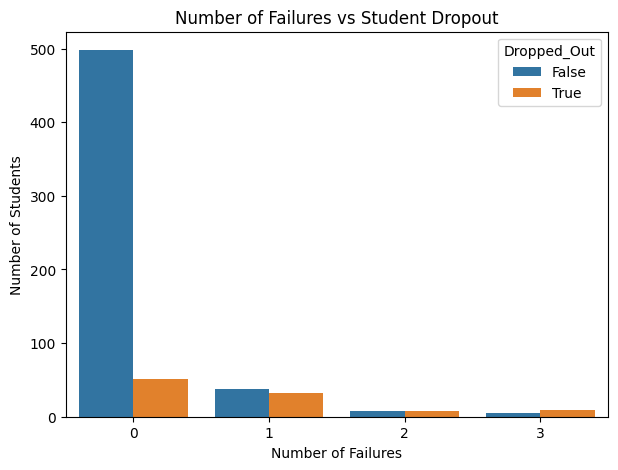

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Number_of_Failures", hue="Dropped_Out")

plt.title("Number of Failures vs Student Dropout")
plt.xlabel("Number of Failures")
plt.ylabel("Number of Students")
plt.show()

# Study Time vs Dropout

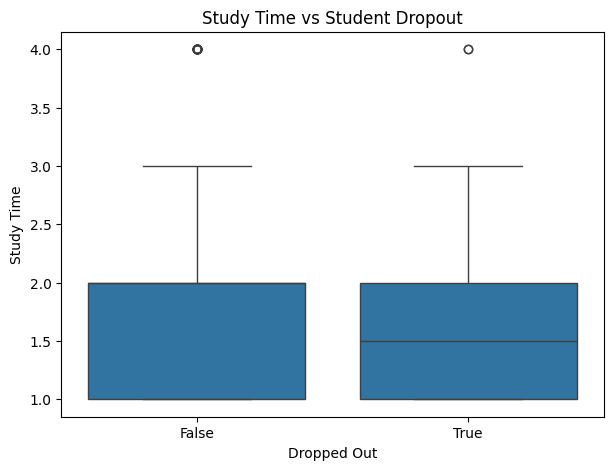

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Dropped_Out", y="Study_Time")

plt.title("Study Time vs Student Dropout")
plt.xlabel("Dropped Out")
plt.ylabel("Study Time")
plt.show()

# Absences vs Dropout

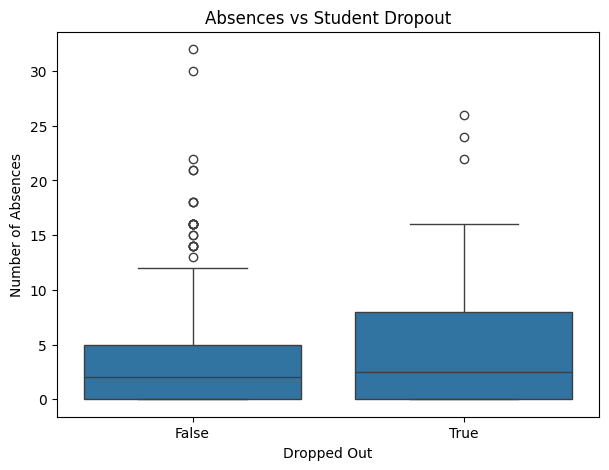

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Dropped_Out", y="Number_of_Absences")

plt.title("Absences vs Student Dropout")
plt.xlabel("Dropped Out")
plt.ylabel("Number of Absences")
plt.show()

# Feature Relationships

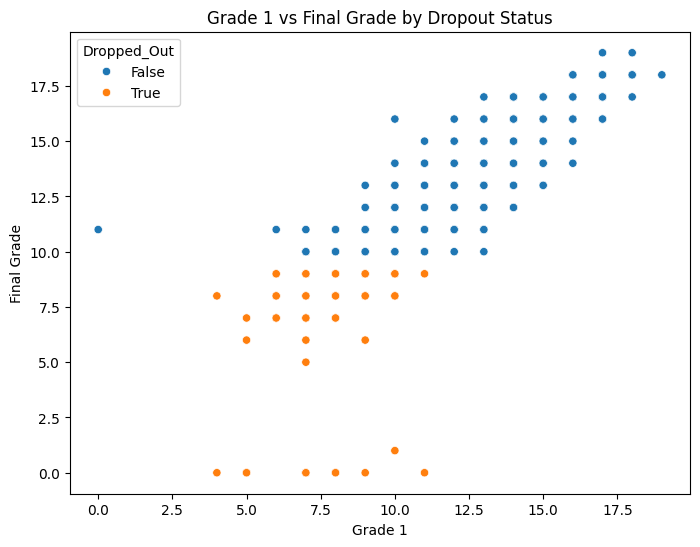

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Grade_1",
    y="Final_Grade",
    hue="Dropped_Out"
)

plt.title("Grade 1 vs Final Grade by Dropout Status")
plt.xlabel("Grade 1")
plt.ylabel("Final Grade")
plt.show()

In [ ]:
df['Dropped_Out'].value_counts()

,count
Dropped_Out,
False,549
True,100


# Separate features and target

In [ ]:
X=df.drop('Dropped_Out',axis=1)
y=df['Dropped_Out']

In [ ]:
# Identify categorical and numerical columns

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['School', 'Gender', 'Address', 'Family_Size', 'Parental_Status', 'Mother_Job', 'Father_Job', 'Reason_for_Choosing_School', 'Guardian', 'School_Support', 'Family_Support', 'Extra_Paid_Class', 'Extra_Curricular_Activities', 'Attended_Nursery', 'Wants_Higher_Education', 'Internet_Access', 'In_Relationship']

Numerical columns:
['Age', 'Mother_Education', 'Father_Education', 'Travel_Time', 'Study_Time', 'Number_of_Failures', 'Family_Relationship', 'Free_Time', 'Going_Out', 'Weekend_Alcohol_Consumption', 'Weekday_Alcohol_Consumption', 'Health_Status', 'Number_of_Absences', 'Grade_1', 'Grade_2', 'Final_Grade']


# Preprocessor

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_cols
        )
    ]
)

# Split into training and testing data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (519, 33)
Testing data: (130, 33)


# Train Logistic Regression

In [ ]:
# Complete ML Pipeline
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)


# Train model
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['School', 'Gender',
                                                   'Address', 'Family_Size',
                                                   'Parental_Status',
                                                   'Mother_Job', 'Father_Job',
                                                   'Reason_for_Choosing_School',
                                                   'Guardian', 'School_Support',
                                                   'Family_Support',
                                                   'Extra_Paid_Class',
                                                   'Extra_Curricular_Activities',
                                                   'Attended_Nursery',
                                                   'Wa...
                                                 ('numerical', StandardScaler(),
                                                  ['Age', 'Mother_Education',
                                                   'Father_Education',
                                                   'Travel_Time', 'Study_Time',
                                                   'Number_of_Failures',
                                                   'Family_Relationship',
                                                   'Free_Time', 'Going_Out',
                                                   'Weekend_Alcohol_Consumption',
                                                   'Weekday_Alcohol_Consumption',
                                                   'Health_Status',
                                                   'Number_of_Absences',
                                                   'Grade_1', 'Grade_2',
                                                   'Final_Grade'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

# Prediction

In [ ]:
y_pred = model_pipeline.predict(X_test)

In [ ]:
# Prediction probabilities

y_prob = model_pipeline.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9786363636363635


# Accuracy

In [ ]:
accuracy_score(y_test, y_pred)

0.9692307692307692

# Confusion Matrix

In [ ]:
confusion_matrix(y_test,y_pred)

array([[108,   2],
       [  2,  18]])

# Classification Report

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.98      0.98      0.98       110
        True       0.90      0.90      0.90        20

    accuracy                           0.97       130
   macro avg       0.94      0.94      0.94       130
weighted avg       0.97      0.97      0.97       130



In [ ]:
import joblib

joblib.dump(model_pipeline, "/content/drive/MyDrive/Student_Dropout_Prediction/model.pkl")

['/content/drive/MyDrive/Student_Dropout_Prediction/model.pkl']